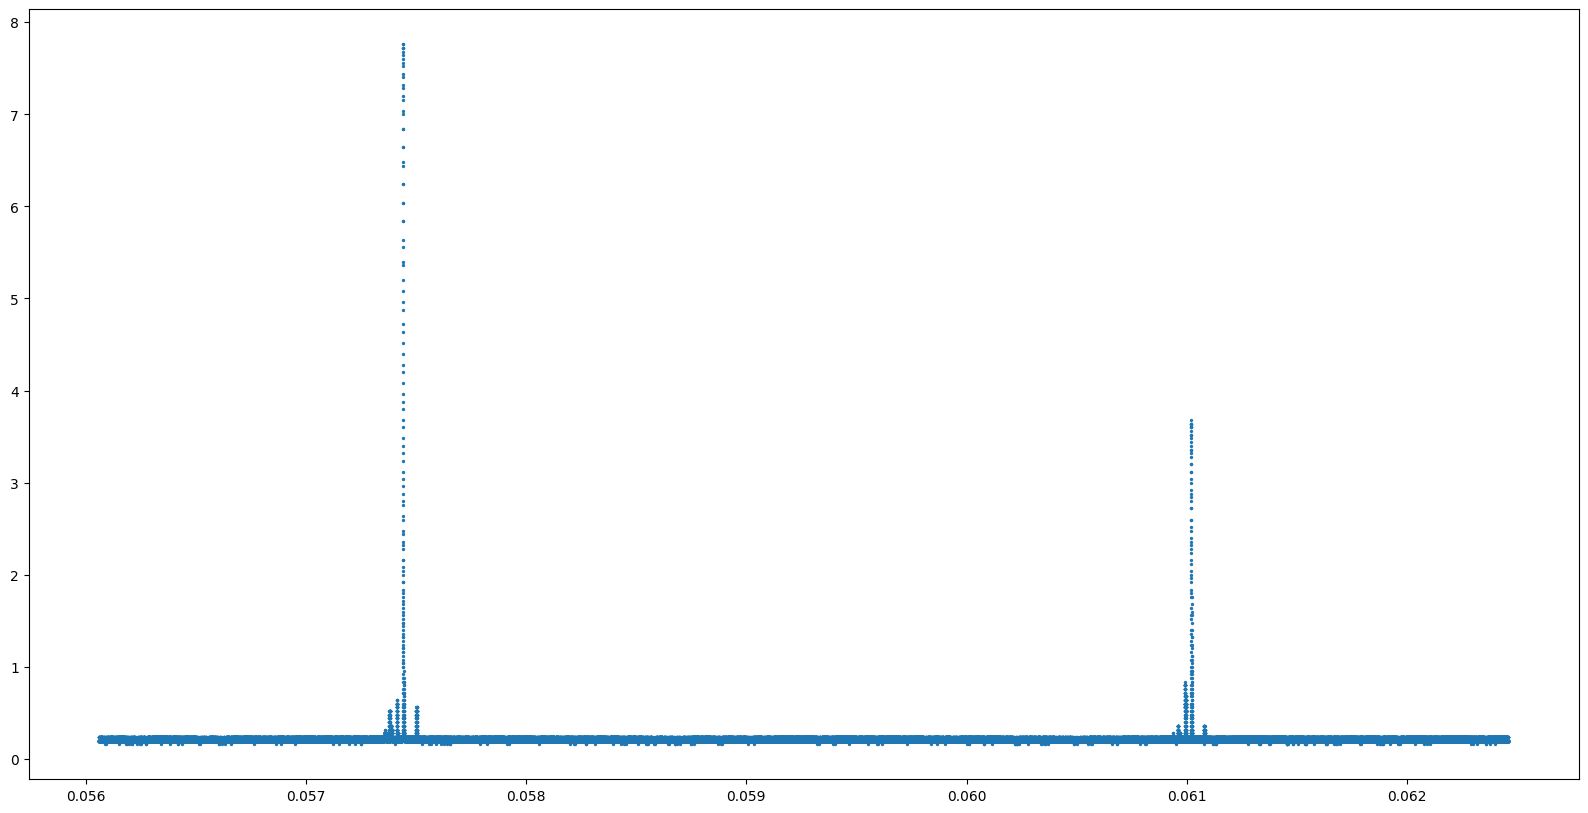

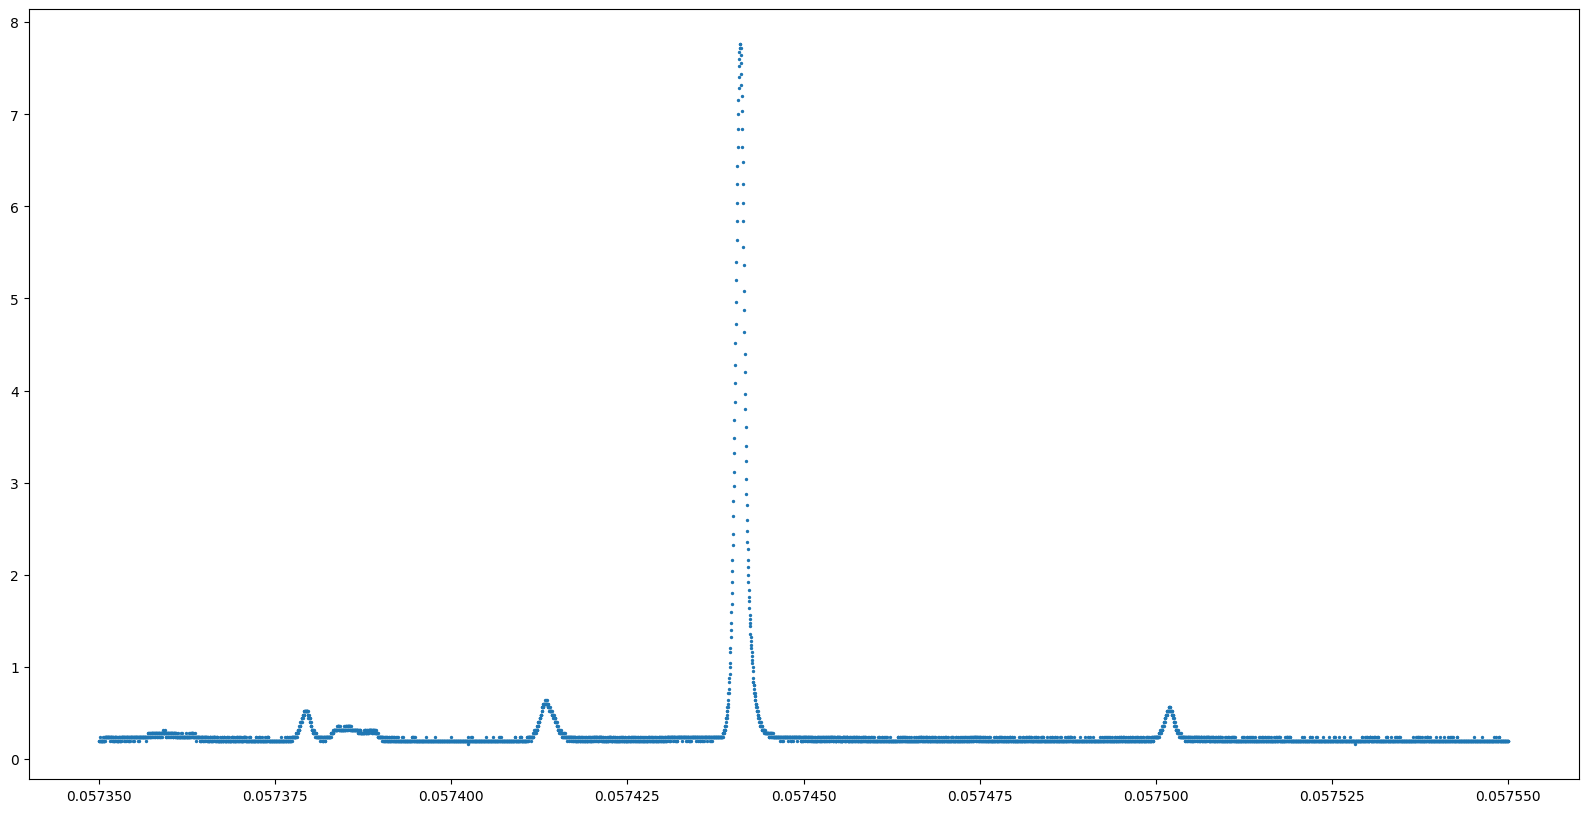

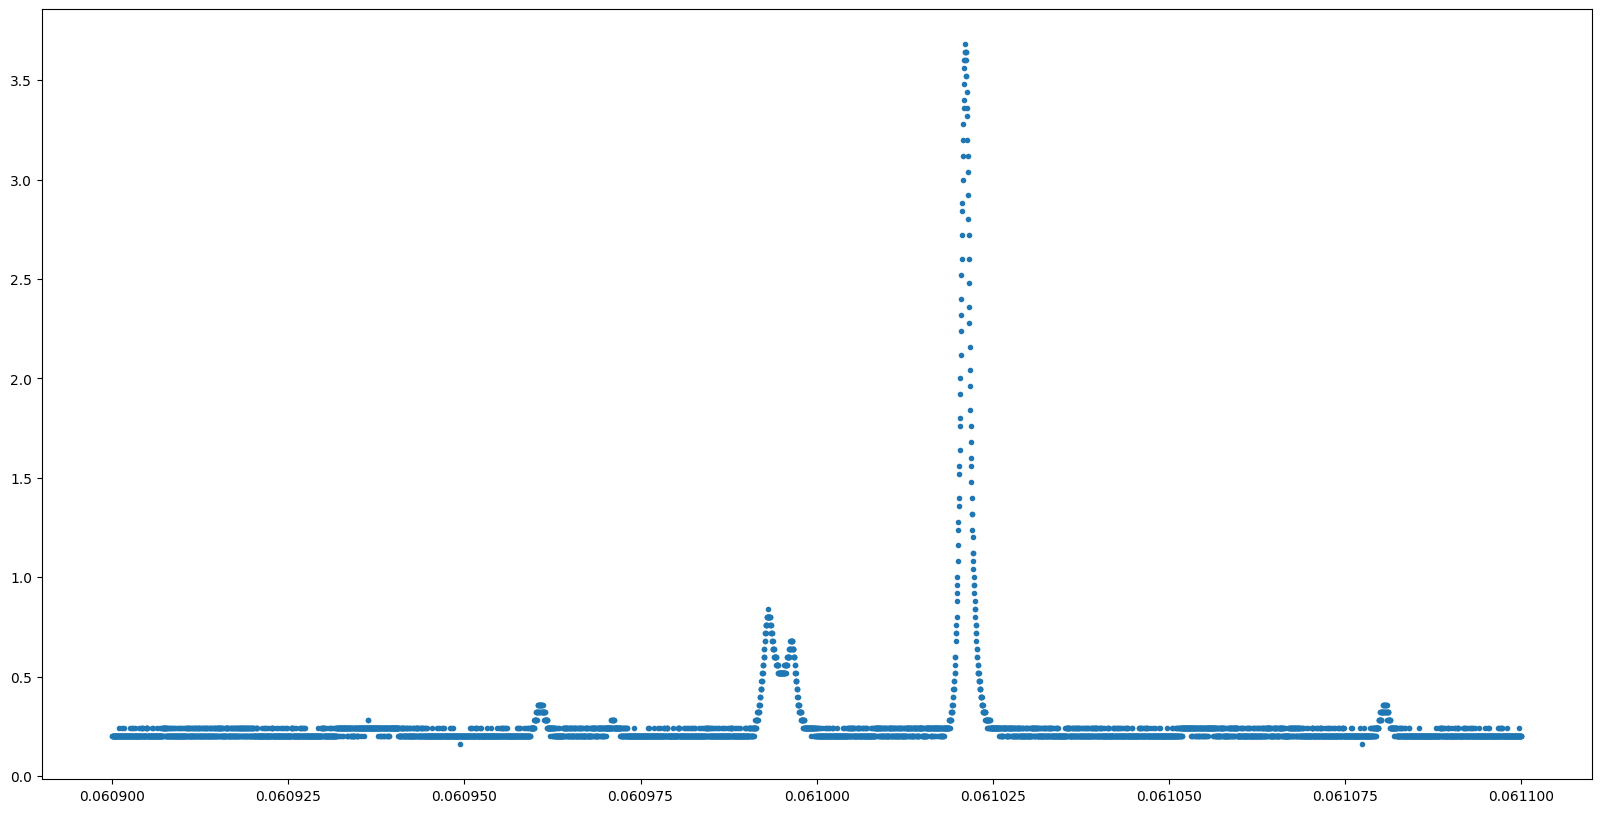

In [55]:
import pandas as pd   
import numpy as np
import matplotlib.pyplot as plt  
from scipy.optimize import curve_fit 

data = pd.read_csv(r"C:\Users\rsrut\OneDrive\Desktop\pythonapps\fp cavity data\TEK00005.CSV")

plt.figure(figsize=(20,10))
plt.scatter(data['TIME'],data['CH2'],s=2)

data1=data[(data['TIME']>0.05735) & (data['TIME']<0.05755)]

plt.figure(figsize=(20,10))
plt.scatter(data1['TIME'],data1['CH2'],s=2)


data2=data[(data['TIME']>0.0609) & (data['TIME']<0.0611)]

plt.figure(figsize=(20,10))
plt.scatter(data2['TIME'],data2['CH2'],s=9)



In [76]:
def lorentzian(x, A1, A2, A3,y1, x1, x2,x3, gamma1, gamma2,gamma3):
    return (y1 + A1 * gamma1**2 / ((x - x1)**2 + gamma1**2) + A2 * gamma2**2 / ((x - x2)**2 + gamma2**2)+A3 * gamma3**2 / ((x - x3)**2 + gamma3**2))



[3.18423037e-01 8.00315715e+00 3.55212303e-01 2.06389674e-01
 5.73793613e-02 5.74409815e-02 5.75018884e-02 7.87267951e-07
 6.25822540e-07 7.04031454e-07]
mean= 6.12635358739344e-05
1 second= 408073083660.13965
line width= 0.2553813336294315


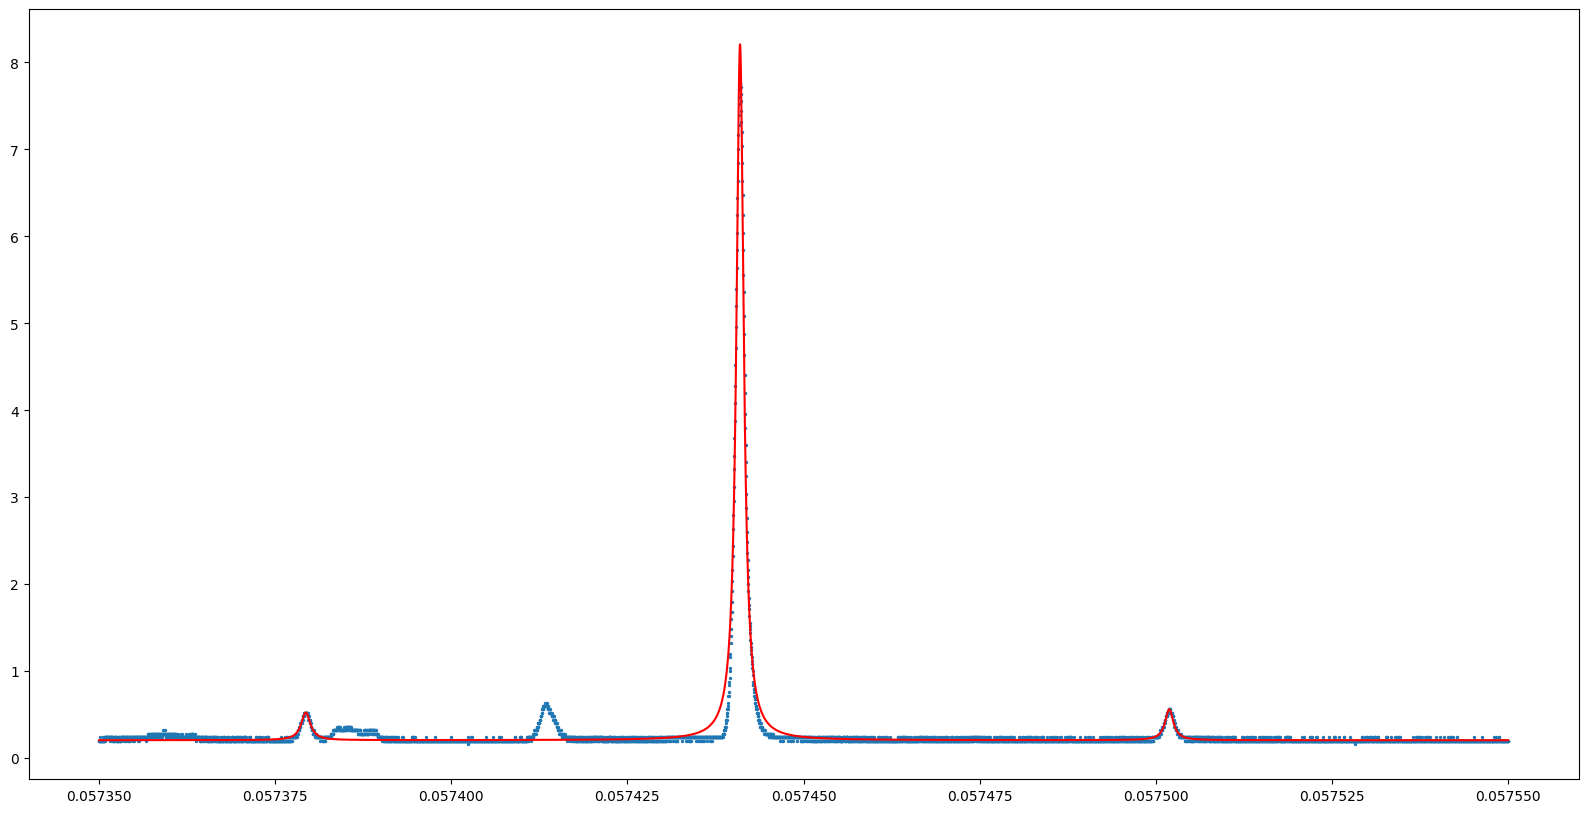

In [85]:
param, param_cov = curve_fit(lorentzian, data1['TIME'], data1['CH2'],p0=(0.21, 7.5, 0.21,0.13, 0.057379, 0.057442,0.057503, 0.0000005,0.0000009,0.0000005))
A1, A2, A3,y1, x1, x2,x3, gamma1, gamma2,gamma3= param
print(param)

mean= ((x2-x1)+(x3-x2))/2
print("mean=", mean)

freq= (25*10**6)/mean
print("1 second=", freq)

line_width1= freq*gamma2
print("line width=",line_width1*10**(-6))

plt.figure(figsize=(20,10))
plt.scatter(data1['TIME'],data1['CH2'],s=2)
plt.plot(data1['TIME'],lorentzian(data1['TIME'],*param),'r')

[1.46851062e-01 3.62637623e+00 1.41453714e-01 2.17886036e-01
 6.09607980e-02 6.10210778e-02 6.10805722e-02 5.23208431e-07
 6.13882807e-07 4.68938310e-07]
mean= 5.9887130713053016e-05
1 second= 417451958414.68146
line width= 0.25626657997301644


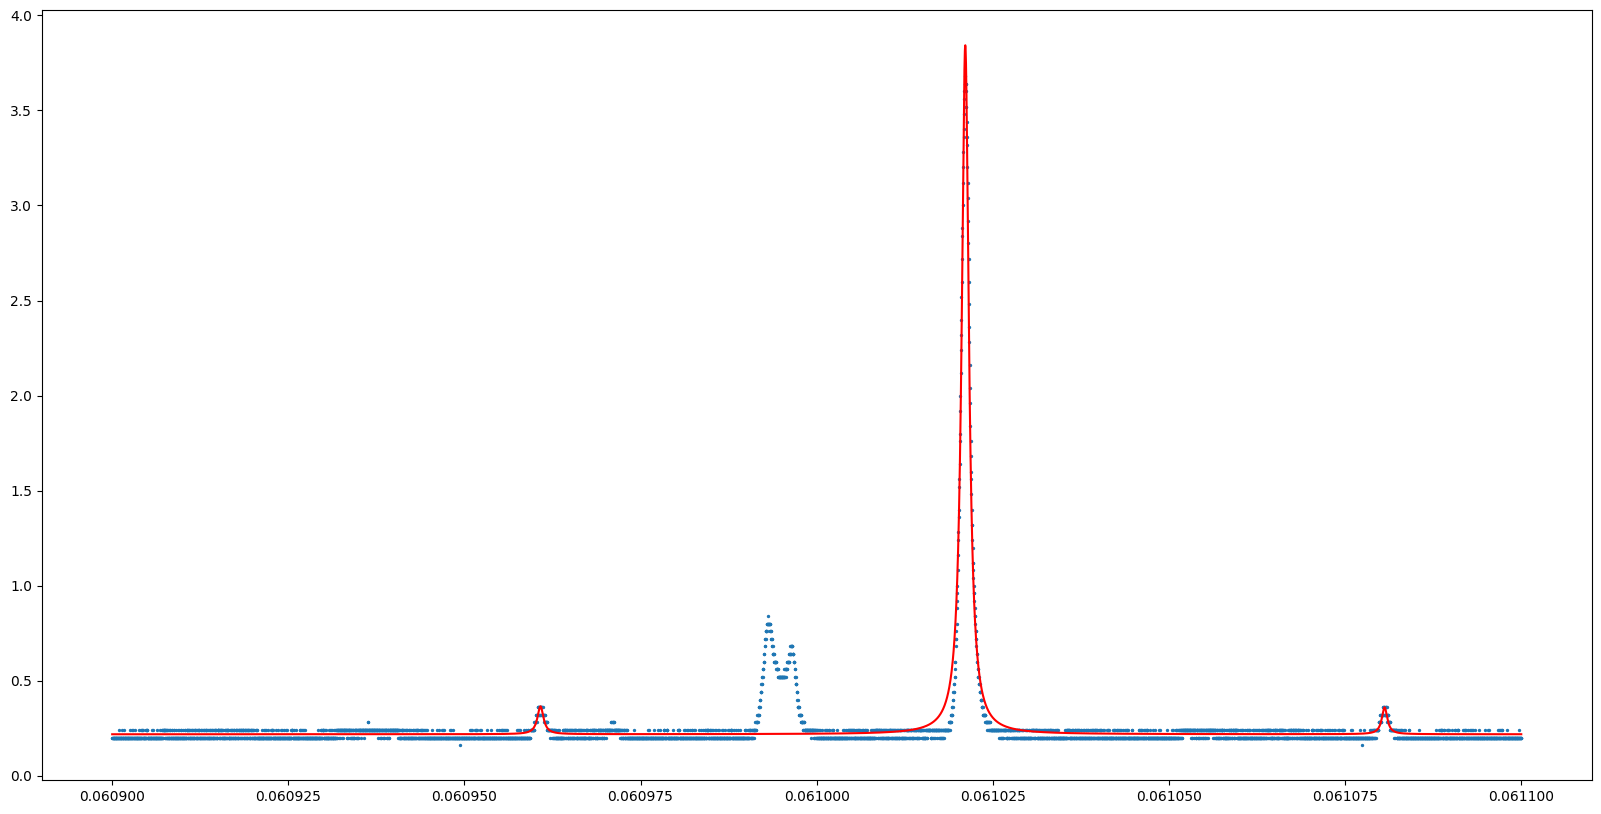

In [86]:
param, param_cov = curve_fit(lorentzian, data2['TIME'], data2['CH2'],p0=( 0.3, 7.5, 0.3,0.13, 0.060960, 0.061020,0.061081, 0.0000005,0.0000009,0.0000005))
A1, A2, A3,y1, x1, x2,x3, gamma1, gamma2,gamma3 = param
print(param)

mean= ((x2-x1)+(x3-x2))/2
print("mean=", mean)

freq= (25*10**6)/mean
print("1 second=", freq)

line_width2= freq*gamma2
print("line width=",line_width2*10**(-6))

plt.figure(figsize=(20,10))
plt.scatter(data2['TIME'],data2['CH2'],s=2)
plt.plot(data2['TIME'],lorentzian(data2['TIME'],*param),'r')

In [88]:
print("line width=",(line_width1+line_width2)*10**(-6)/2)

line width= 0.25582395680122394
